# Value Equivalence (MuZero)

**Companion to** [`research/08-value-equivalence-muzero.md`](../research/08-value-equivalence-muzero.md).

The value-equivalence principle says a model does **not** need to reconstruct observations — it only needs to
predict value, policy, and reward correctly to support planning. MuZero builds its abstract latent with no
decoder and no reconstruction loss. This notebook demonstrates *why* that is a good use of limited capacity,
*how* the abstract state is non-unique, and *what* the value-equivalent model class looks like.

**What we will see:**

1. **Where capacity goes** — under observation distractors, a reconstruction model wastes its bottleneck on
   high-variance noise and predicts reward poorly; a value-equivalent model ignores the noise and nails it.
2. **Abstract state is non-unique** — a value-equivalence-preserving transform produces a completely different
   latent trajectory with *identical* value predictions; the latent has no intrinsic meaning.
3. **The VE class shrinks** — as you require equivalence on more value functions, the set of value-equivalent
   models collapses toward the true model (the Grimm proper-value-equivalence picture).
4. **Abstraction payoff** — a value-equivalent model merges value-irrelevant state distinctions and plans
   optimally with fewer states than a reconstruction model must keep.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: where the capacity goes (reconstruction vs value-equivalence)

**Question.** With a small latent bottleneck, what does a reconstruction objective learn versus a value
(reward) objective?

Observation $o = [\,s,\ \text{distractor}\,]$: a 2-D task-relevant signal $s$ plus a high-dimensional
distractor of variance $\sigma^2$ that has nothing to do with reward $r = w\cdot s$. We compress $o$ to a 2-D
latent two ways — **reconstruction** (top-2 PCA, minimizes $\lVert\hat o-o\rVert^2$) and **value-equivalent**
(the 2-D linear subspace that best predicts reward) — and measure reward-prediction $R^2$ as the distractor
grows.

In [2]:
def experiment(noise_std, n=4000, d_noise=50, seed=0):
    rng = np.random.default_rng(seed)
    s = rng.standard_normal((n, 2))                       # task-relevant signal
    w = np.array([1.5, -1.0]); r = s @ w                  # reward depends only on s
    noise = noise_std * rng.standard_normal((n, d_noise))
    o = np.concatenate([s, noise], axis=1)
    o = o - o.mean(0)

    # reconstruction latent: top-2 principal components of o
    U, S, Vt = np.linalg.svd(o, full_matrices=False)
    Zrec = o @ Vt[:2].T
    # value-equivalent latent: 2-D projection trained to predict reward (partial least squares-ish):
    # take the reward-direction in o-space, plus the residual best predictor
    b = np.linalg.lstsq(o, r, rcond=None)[0]              # full linear reward predictor
    dir1 = b / np.linalg.norm(b)
    o_res = o - np.outer(o @ dir1, dir1)
    b2 = np.linalg.lstsq(o_res, r - o @ dir1 * (dir1 @ b), rcond=None)[0]
    dir2 = b2 / (np.linalg.norm(b2) + 1e-9)
    Zve = np.column_stack([o @ dir1, o @ dir2])

    def r2(Z):
        c = np.linalg.lstsq(np.column_stack([Z, np.ones(n)]), r, rcond=None)[0]
        pred = np.column_stack([Z, np.ones(n)]) @ c
        return 1 - np.var(r - pred) / np.var(r)
    return r2(Zrec), r2(Zve)

stds = [0.3, 0.6, 1.0, 2.0, 4.0, 8.0]
rec_r2, ve_r2 = [], []
for sd in stds:
    a, b = experiment(sd)
    rec_r2.append(a); ve_r2.append(b)
    print(f'noise_std={sd:>4}: reconstruction R^2={a:.3f} | value-equiv R^2={b:.3f}')

noise_std= 0.3: reconstruction R^2=1.000 | value-equiv R^2=1.000
noise_std= 0.6: reconstruction R^2=0.996 | value-equiv R^2=1.000
noise_std= 1.0: reconstruction R^2=0.093 | value-equiv R^2=1.000
noise_std= 2.0: reconstruction R^2=0.001 | value-equiv R^2=1.000
noise_std= 4.0: reconstruction R^2=0.001 | value-equiv R^2=1.000
noise_std= 8.0: reconstruction R^2=0.001 | value-equiv R^2=1.000


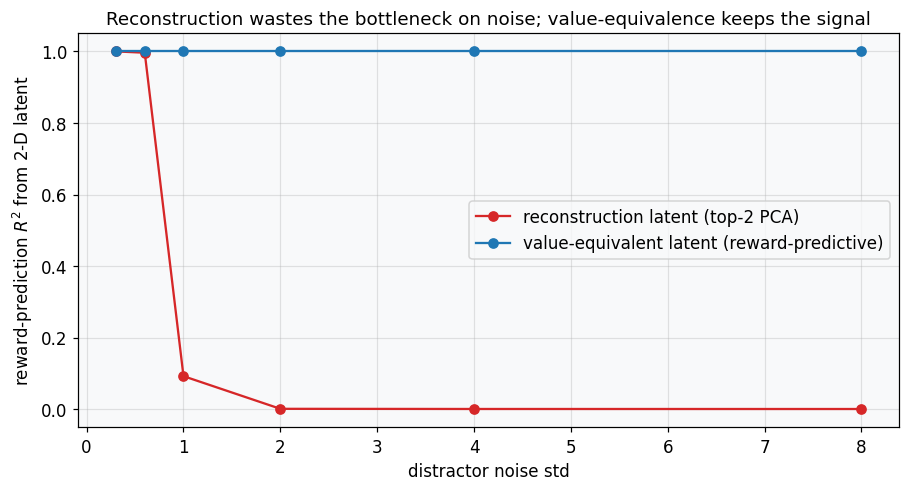

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(stds, rec_r2, '-o', color='#d62728', label='reconstruction latent (top-2 PCA)')
ax.plot(stds, ve_r2, '-o', color='#1f77b4', label='value-equivalent latent (reward-predictive)')
ax.set_xlabel('distractor noise std'); ax.set_ylabel('reward-prediction $R^2$ from 2-D latent')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Reconstruction wastes the bottleneck on noise; value-equivalence keeps the signal')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

When the distractor is small, both latents predict reward well. As the distractor variance grows, the
reconstruction latent's reward $R^2$ collapses toward zero, while the value-equivalent latent stays near 1.

**Why.** PCA (reconstruction) keeps the *highest-variance* directions of $o$. Once the distractor dominates the
variance, the top-2 components are pure noise — faithfully reconstructable, but useless for reward. The
value-equivalent latent is built to predict reward, so it locks onto the 2-D signal subspace and ignores the
noise no matter how loud it gets.

**Takeaway.** Reconstruction spends capacity in proportion to *pixel variance*; value-equivalence spends it in
proportion to *task relevance*. This is exactly why MuZero drops the decoder — in real observations, most
variance (texture, background) is a distractor for the reward.

## Experiment 2: the abstract state is non-unique

**Question.** If the latent only has to make value predictions come out right, is it pinned down?

No. Take a value-equivalent model: latent transition $s_{t+1}=T s_t$ and value head $v_t=w^\top s_t$. For *any*
invertible $P$, the transformed model $T'=P T P^{-1}$, $w'=P^{-\top}w$, acting on $s'_t=Ps_t$, produces the
**identical** value sequence. We show two such models side by side.

In [4]:
theta = 0.25
T = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]) * 0.97
w = np.array([1.0, 0.5]); s0 = np.array([1.5, -1.0])
P = np.array([[1.2, 0.7], [-0.4, 1.5]])                  # arbitrary invertible transform
Tp = P @ T @ np.linalg.inv(P)
wp = np.linalg.inv(P).T @ w

def rollout(T, w, s0, H=30):
    s = s0.copy(); S, V = [s.copy()], [w @ s]
    for _ in range(H):
        s = T @ s; S.append(s.copy()); V.append(w @ s)
    return np.array(S), np.array(V)

S1, V1 = rollout(T, w, s0)
S2, V2 = rollout(Tp, wp, P @ s0)
print('max |value difference| between the two models:', np.max(np.abs(V1 - V2)))

max |value difference| between the two models: 7.494005416219807e-16


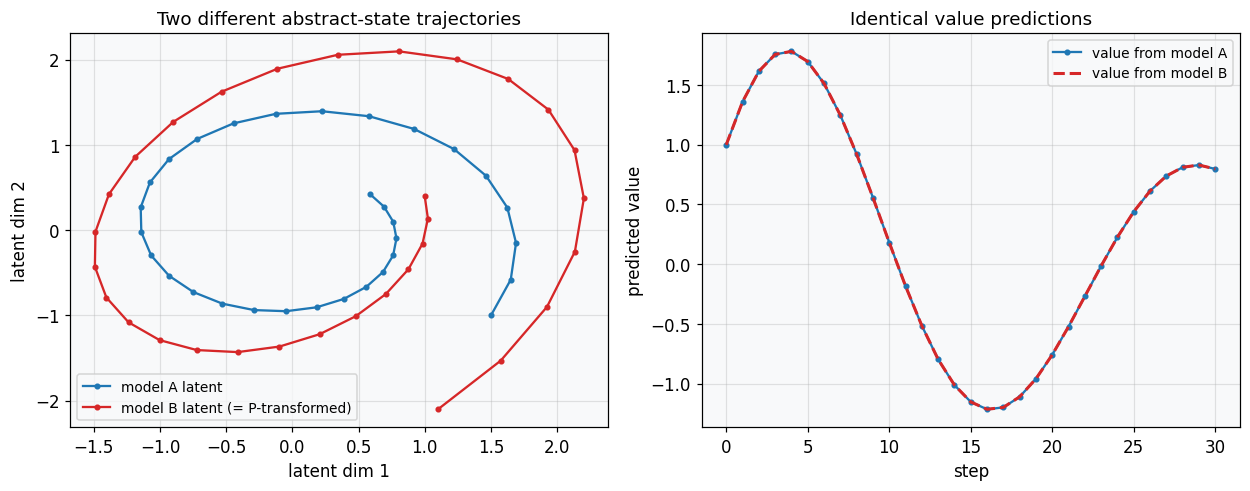

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.6))
axL.plot(S1[:, 0], S1[:, 1], '-o', ms=3, color='#1f77b4', label='model A latent')
axL.plot(S2[:, 0], S2[:, 1], '-o', ms=3, color='#d62728', label='model B latent (= P-transformed)')
axL.set_xlabel('latent dim 1'); axL.set_ylabel('latent dim 2')
axL.set_title('Two different abstract-state trajectories'); axL.legend(fontsize=9)

axR.plot(V1, '-o', ms=3, color='#1f77b4', label='value from model A')
axR.plot(V2, '--', lw=2, color='#d62728', label='value from model B')
axR.set_xlabel('step'); axR.set_ylabel('predicted value')
axR.set_title('Identical value predictions'); axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The two latent trajectories (left) trace completely different paths in different coordinates, yet their value
predictions (right) coincide to machine precision. Model B is just model A viewed through an invertible
change of basis, with the transition and value head transformed consistently.

**Why.** Value equivalence only constrains the *functional* output $w^\top s$. Any reparameterization
$s\mapsto Ps$ that the heads and dynamics absorb leaves every value identical. The abstract state therefore
has no intrinsic geometry — only its role in producing value/reward/policy is determined.

**Takeaway.** "What does the abstract state mean?" is the wrong question for a value-equivalent model — there is
a whole equivalence class of latents giving the same plans. This is why MuZero's learned states need not
correspond to real environment states, and why they are hard to interpret or decode.

## Experiment 3: the value-equivalent model class shrinks

**Question.** Grimm et al. say the set of value-equivalent models shrinks as you demand equivalence on more
value functions. Can we measure that?

On an $n_S$-state MDP with true transition $P$, a model $\hat P$ is value-equivalent w.r.t. a value function
$v$ if each row gives the same expected next-value: $\hat P_i\cdot v = P_i\cdot v$. With $m$ random value
functions stacked as columns of $V\in\mathbb{R}^{n_S\times m}$, each row of $\hat P$ must satisfy $m$ linear
constraints. We count the remaining free dimensions per row as $m$ grows.

In [6]:
nS = 8
rng = np.random.default_rng(1)
free_dims = []
ms = np.arange(0, nS + 1)
for m in ms:
    if m == 0:
        free_dims.append(nS)                              # unconstrained row
    else:
        V = rng.standard_normal((nS, m))                  # m value functions
        free_dims.append(nS - np.linalg.matrix_rank(V))   # null-space dim of constraints
for m, fd in zip(ms, free_dims):
    print(f'{m} value functions -> {fd} free parameters per row of the model')

0 value functions -> 8 free parameters per row of the model
1 value functions -> 7 free parameters per row of the model
2 value functions -> 6 free parameters per row of the model
3 value functions -> 5 free parameters per row of the model
4 value functions -> 4 free parameters per row of the model
5 value functions -> 3 free parameters per row of the model
6 value functions -> 2 free parameters per row of the model
7 value functions -> 1 free parameters per row of the model
8 value functions -> 0 free parameters per row of the model


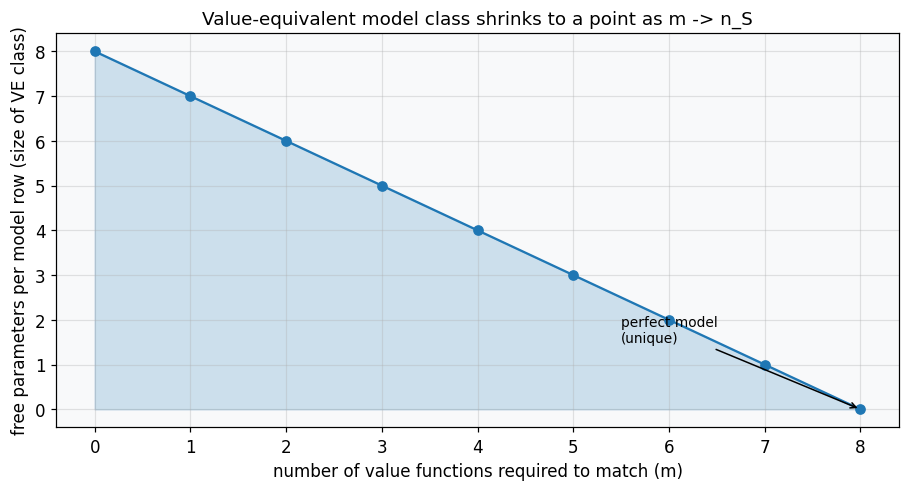

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(ms, free_dims, '-o', color='#1f77b4')
ax.fill_between(ms, free_dims, alpha=0.2, color='#1f77b4')
ax.set_xlabel('number of value functions required to match (m)')
ax.set_ylabel('free parameters per model row (size of VE class)')
ax.set_title('Value-equivalent model class shrinks to a point as m -> n_S')
ax.annotate('perfect model\n(unique)', xy=(nS, 0), xytext=(nS - 2.5, 1.5),
            arrowprops=dict(arrowstyle='->'), fontsize=9)
plt.tight_layout(); plt.show()

### What you see

With zero required value functions, every model row is free ($n_S$ parameters) — any model is trivially
"value-equivalent". Each additional value function imposes one independent linear constraint, shrinking the
free dimensions one by one, until at $m=n_S$ the row is pinned to the true model: the value-equivalent class
collapses to a single point.

**Why.** Matching a Bellman backup on $v$ is the linear constraint $\hat P_i\cdot v=P_i\cdot v$. Independent
$v$'s carve down the solution space; once they span $\mathbb{R}^{n_S}$ the only consistent model is the exact
one. This is the proper-value-equivalence picture: more functions/policies $\Rightarrow$ smaller VE class.

**Takeaway.** Value equivalence is a *spectrum*, set by how many value functions and policies you require it to
serve. The art (Grimm 2021) is choosing the smallest set sufficient for planning — enough to plan well, few
enough that the model stays cheap and ignores irrelevant detail.

## Experiment 4: abstraction payoff — plan optimally with fewer states

**Question.** What does dropping value-irrelevant distinctions actually buy?

We build a control MDP, then *duplicate* every state into a value-equivalent twin (identical reward and
transition behavior). A reconstruction model must keep all $2n_S$ observation-distinct states; a
value-equivalent model merges each twin pair into one abstract state. We run value iteration on both and check
the optimal policy is unchanged.

In [8]:
nS, nA = 6, 3; gamma = 0.9
rng = np.random.default_rng(2)
P = np.stack([rng.dirichlet(np.ones(nS), size=nS) for _ in range(nA)])   # (nA, nS, nS)
R = rng.standard_normal((nA, nS))

def value_iteration(P, R, nS, nA, iters=500):
    Q = np.zeros((nS, nA))
    for _ in range(iters):
        V = Q.max(1)
        for a in range(nA):
            Q[:, a] = R[a] + gamma * P[a] @ V
    return Q.argmax(1), Q.max(1)

pi_true, V_true = value_iteration(P, R, nS, nA)

# augmented "observation" MDP: each state duplicated into a value-equivalent twin (2*nS states)
def dup(M):  # duplicate rows/cols consistently
    return M
Paug = np.zeros((nA, 2 * nS, 2 * nS)); Raug = np.zeros((nA, 2 * nS))
for a in range(nA):
    for i in range(nS):
        for tw_i in (i, i + nS):
            Raug[a, tw_i] = R[a, i]
            for j in range(nS):
                # split transition mass equally over each target's twin pair (value-equivalent)
                Paug[a, tw_i, j] = P[a, i, j] / 2
                Paug[a, tw_i, j + nS] = P[a, i, j] / 2

pi_aug, V_aug = value_iteration(Paug, Raug, 2 * nS, nA)
# map augmented optimal policy back to original states (both twins should agree)
agree = np.all(pi_aug[:nS] == pi_true) and np.all(pi_aug[nS:] == pi_true)
print('reconstruction model states:', 2 * nS, '| value-equivalent abstract states:', nS)
print('optimal policy preserved after merging twins:', bool(agree))
print('value match (twin i vs i):', np.allclose(V_aug[:nS], V_aug[nS:], atol=1e-6))

reconstruction model states: 12 | value-equivalent abstract states: 6
optimal policy preserved after merging twins: True
value match (twin i vs i): True


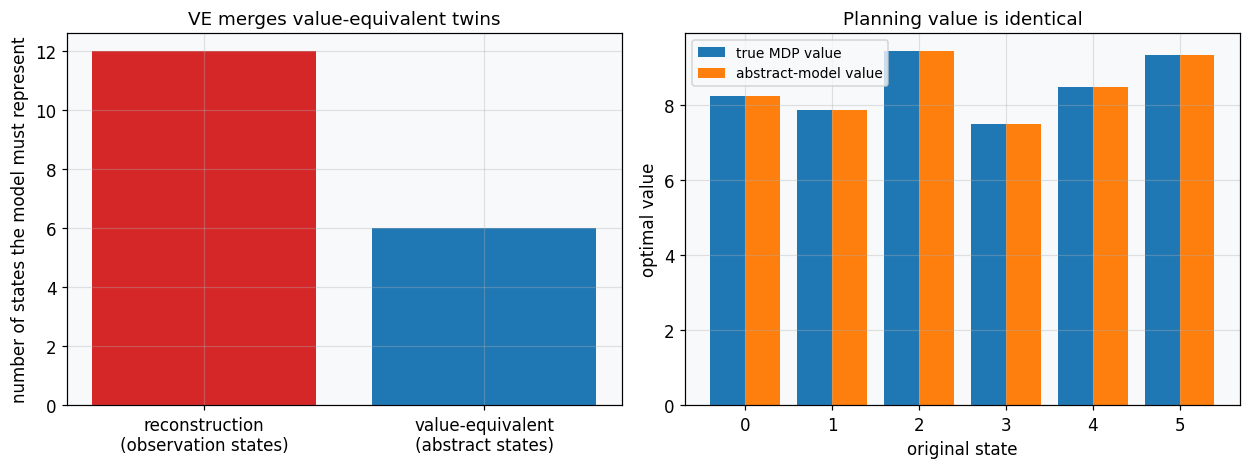

In [9]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.4))
axL.bar(['reconstruction\n(observation states)', 'value-equivalent\n(abstract states)'],
        [2 * nS, nS], color=['#d62728', '#1f77b4'])
axL.set_ylabel('number of states the model must represent')
axL.set_title('VE merges value-equivalent twins')

x = np.arange(nS)
axR.bar(x - 0.2, V_true, 0.4, color='#1f77b4', label='true MDP value')
axR.bar(x + 0.2, V_aug[:nS], 0.4, color='#ff7f0e', label='abstract-model value')
axR.set_xlabel('original state'); axR.set_ylabel('optimal value')
axR.set_title('Planning value is identical'); axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The reconstruction model has to carry all $2n_S$ observation-distinct states (red bar), while the
value-equivalent model represents only $n_S$ abstract states (blue) — it has merged each twin pair, because the
twins are indistinguishable for value and reward. Value iteration on the abstract model recovers exactly the
true optimal values and policy (right).

**Why.** The twins differ only in "observation identity", which never affects reward or transition-to-value.
Value equivalence treats them as one state; reconstruction must keep them apart to be able to redraw the
observation. The planning-relevant structure is strictly smaller than the observation.

**Takeaway.** A value-equivalent model is the minimal representation sufficient for planning — it compresses
away exactly the distinctions a decoder would be forced to preserve. Less to learn, less to roll out, and no
loss in plan quality: the upside that pays for losing decodability.

## Summary / Key Takeaways

- **Capacity (Exp 1)** — reconstruction spends the latent on high-variance pixels; value-equivalence spends it
  on reward-relevant structure, so it predicts value far better under distractors. This is why MuZero has no
  decoder.
- **Non-uniqueness (Exp 2)** — any invertible reparameterization gives a different abstract state with
  identical value predictions; the latent has no intrinsic meaning, only a functional role.
- **Shrinking class (Exp 3)** — requiring equivalence on more value functions linearly shrinks the
  value-equivalent model class toward the unique true model (proper value equivalence).
- **Abstraction payoff (Exp 4)** — a value-equivalent model merges value-irrelevant state distinctions and
  plans optimally with fewer states than a reconstruction model must keep — minimal sufficient structure for
  planning.